# Model a flowing non-viscous fluid using QUICK-PDE

<div class="alert alert-block alert-warning">

**⚠️ Warning: QPU Time Consumption**

Note that the execution time of this function is generally greater than 20 minutes,
so you might want to split this lab in two sections: the first one, in which
you read through it and launch the jobs, and the second one a few hours later
(giving ample time for the jobs to complete), to work with the results of the jobs.

</div>

## Table of Contents

- [Background](#background)
- [Setup](#setup)
- [Step 1: Set properties of the problem to solve](#step-1)
- [Step 2 (if needed): Optimize problem for quantum hardware execution](#step-2)
- [Step 3: Use the result](#step-3)

## Background

This lab seeks to teach on an introductory level how to use the QUICK-PDE
function to solve complex multi-physics problems on 156Q Heron R2 QPUs by using
ColibriTD's H-DES (Hybrid Differential Equation Solver). 
The underlying algorithm is described in [the H-DES paper.](https://arxiv.org/abs/2410.01130).
Note that this solver can also solve non-linear equation. 

Multi-physics problems - including fluids dynamics, heat diffusion, and material
deformation, to name a few - can be ubiquitously described by Partial
Differential Equations (PDEs).

Such problems are highly relevant for various industries and constitute an
important branch of applied mathematics. However, solving non-linear
multivariate coupled PDEs with classical tools remains challenging due to the
requirement of an exponentially large amount of resources.

This function is appropriate for equations with increasing complexity and
variables, and is the first step to unlock possibilities that were once
considered intractable. To fully describe a problem modeled by PDEs, it is
necessary to know the initial and boundary conditions. These can strongly
change the solution of the PDE and the path to find their solution.

In this lab, you will learn how to:

1. Define the parameters of the initial condition function.
2. Adjust the qubit number (used to encode the function of the differential equation), depth, and shot number. 
3. Run QUICK-PDE to solve the underlying differential equation.

## Setup

In [1]:
# Install dependencies
%pip install "qc-grader[qiskit,jupyter] @ git+https://github.com/qiskit-community/Quantum-Challenge-Grader.git"
%pip install "qiskit[visualization]" qiskit_ibm_catalog

Defaulting to user installation because normal site-packages is not writeable
  Cloning https://github.com/qiskit-community/Quantum-Challenge-Grader.git to /tmp/pip-install-9tq6q5mf/qc-grader_c44cd18bea9443d682d70b84b91ff150
  Running command git clone --filter=blob:none --quiet https://github.com/qiskit-community/Quantum-Challenge-Grader.git /tmp/pip-install-9tq6q5mf/qc-grader_c44cd18bea9443d682d70b84b91ff150
  Resolved https://github.com/qiskit-community/Quantum-Challenge-Grader.git to commit 1d7a6915623b0cfeac4c114391c279e9d98eb7f9
  Preparing metadata (setup.py) ... done
Note: you may need to restart the kernel to use updated packages.
Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [2]:
import qc_grader

print(f"Grader version: {qc_grader.__version__}")

Grader version: 0.22.12


You should have Grader `>=0.22.11`. If you see a lower version, you need to restart your kernel and reinstall the grader.

In [3]:
# Imports
from qiskit_ibm_catalog import QiskitFunctionsCatalog
import numpy as np
import matplotlib.pyplot as plt
from grader import grade_ex1, grade_ex2, grade_ex3
from qc_grader.challenges.qgss_2025 import grade_colibritd_function

<div class="alert alert-block alert-warning">

**Exclusive Access to Qiskit Functions**

As part of Qiskit Global Summer School (QGSS), participants with a Premium or Flex Plan have limited-time trial access to Qiskit Functions. Access is exclusive and subject to your organization’s administrator approval. Complete [this form](https://airtable.com/appj8IrSNZGz4l4BB/pag8WgWdUr5uSJGZA/form) to request access.

If you encounter the error `QiskitServerlessException: Credentials couldn't be verified`. in the cell below, it means your access to Qiskit Functions is not yet active. Please check back later after your request has been processed.

**Note: Running this lab will consume QPU time from your organization’s account. Estimated QPU usage is provided before each cell that executes on a QPU. Please monitor your usage and consult your organization admin if you’re unsure about your allocated QPU time for QGSS Functions labs.**

</div>

In [ ]:
# Load the Qiskit Functions Catalog
your_api_key = "deleteThisAndPasteYourAPIKeyHere"
your_crn = "deleteThisAndPasteYourCRNHere"

catalog = QiskitFunctionsCatalog(
    channel="ibm_quantum_platform",
    token=your_api_key,
    instance=your_crn,
)
# You should see a list of Qiskit Functions available to you
# If you encounter the error `QiskitServerlessException: Credentials couldn't be verified`,
# it means your access is not yet active
catalog.list()

[QiskitFunction(qunova/hivqe-chemistry),
 QiskitFunction(global-data-quantum/quantum-portfolio-optimizer),
 QiskitFunction(algorithmiq/tem),
 QiskitFunction(qedma/qesem),
 QiskitFunction(multiverse/singularity),
 QiskitFunction(q-ctrl/optimization-solver),
 QiskitFunction(colibritd/quick-pde),
 QiskitFunction(q-ctrl/performance-management),
 QiskitFunction(kipu-quantum/iskay-quantum-optimizer)]

<div class="alert alert-block alert-success">
    
<b> Load Qiskit Function</b>

Find the correct function name from the list above, or refer to the [Qiskit Functions Catalog](https://quantum.cloud.ibm.com/functions) to locate the appropriate function name string. The name should follow the format: `"[provider]/[title]"`.

</div>

In [5]:
# Load ColibriTD QUICK PDE function

function_name = "colibritd/quick-pde"  # TODO
quick = catalog.load(function_name)

In [6]:
grade_colibritd_function(quick)

Submitting your answer. Please wait...
Congratulations 🎉! Your answer is correct and has been submitted.


<a id="step-1"></a>

## Step 1: Set properties of the problem to solve

This lab covers the user experience from two perspectives: the
physical problem determined by the initial conditions, and the algorithmic
component in solving a fluid dynamics example on a quantum computer. 

Computational Fluid Dynamics (CFD) has a broad range of applications, thus it is
important to study and solve the underlying PDEs. An important family of PDEs
are the Navier-Stokes equations, which are a system of nonlinear partial
differential equations describing the motion of fluids. They are highly relevant
for scientific problems and engineering applications.

Under certain conditions the Navier-Stokes equations reduce to Burger's
equation, a convection–diffusion equation describing phenomena occurring in
fluid dynamics, gas dynamics, and nonlinear acoustic etc. Basically, it models
dissipative systems.

The one-dimensional version of the equation depends on two variables:
$t \in \mathbb{R}_{\geq 0}$ modeling the temporal dimension, $x \in \mathbb{R}$
representing the spatial dimension. The general form of the equation called
viscous Burger's equation and reads:

$$\frac{\partial u}{\partial t} + u \frac{\partial u}{\partial x} = \nu \frac{\partial^2 u}{\partial^2 x},$$

$u(x,t)$ is the fluid speed field at a given position $x$ and time $t$ and $\nu$
is the viscosity of the fluid. Viscosity is an important property of a fluid
measuring its rate-dependent resistance to motion or deformation and thus it
plays a crucial role in the determination of the dynamics of a fluid. When the
viscosity of the fluid is null ($\nu$ = 0), the equation becomes a conservation
equations that can develop discontinuities (shock waves), due to the lack of its
internal resistance. In this case, the equation is called inviscid  Burgers
equation and is a special case of nonlinear wave equation.

Strictly speaking, inviscid flows do not occur in nature, but when modeling
aerodynamic flow, due to the infinitesimal effect of transport, using an
inviscid description of the problem can be very useful. Surprisingly, more than
70% of aerodynamic theory deal with inviscid flows.

In this lab we offer the inviscid Burger equation as CFD example to solve
on IBM devices using QUICK-PDE, given by the equation: 
$$\frac{\partial u}{\partial t} + u\frac{\partial u}{\partial x} = 0, $$ 

The initial condition for this problem is set to a linear function: 
$$u(t=0,x) = ax + b,\text{ with }a,b\in\mathbb{R}$$ 
where $a$ and $b$, are arbitrary constants influencing the shape of the
solution. The user can play with $a$ and $b$ and see how they influence the
solving process and the solution.

<a id="exercise_1"></a>
<div class="alert alert-block alert-success">
<b> Exercise 1: Select the physics problem and set the boundary condition</b> 

Please choose `cfd` as the use case and set the initial conditions with the physical parameters `a=1.0` and `b=1.0`

</div>

In [9]:
### Write your code below here ###
# Select the use case and set the initial condition values. 
use_case = "cfd"
physical_parameters = {
    "a": 1.0,
    "b": 1.0,
}

In [10]:
grade_ex1(use_case,physical_parameters)

'Congratulations 🎉! Your answer is correct.'

<div class="alert alert-block alert-warning">

**⚠️ Warning: QPU Time Consumption**

Running the cell below will submit a job to a QPU and consume real QPU time. Please ensure you intend to proceed.\
If you do not want to run the job, we provide an example output and you can proceed to the second part of the assignment.

**Estimated QPU runtime:** 25 minutes (based on tests on `ibm_aachen`)

</div>

In [ ]:
### Run the quantum job with correct input below here ###
# job = quick.run(
#     use_case=use_case,
#     physical_parameters=physical_parameters,
# )
# job_id = job.job_id
# print(f"Job ID: {job_id}")

In [ ]:
#job.status() # Check the status is DONE before getting the result

The convergences of the VQA can be analyzed by printing the loss function via:

print(job_new.logs())

which for this job would looks like:

backend_name: ibm_aachen

compute_observables...\
compute_observables 9.1829s  
    
optimizers:\
   CMA: {'ftarget': 0.001, 'verb_disp': 1, 'maxiter': 20}\
================== CMA =================\
option:  {'ftarget': 0.001, 'verb_disp': 1, 'maxiter': 20}\
0/20, loss: 0.2252195\
1/20, loss: 0.1865713\
2/20, loss: 0.1585983\
3/20, loss: 0.2128656\
4/20, loss: 0.1606169\
5/20, loss: 0.1201112\
6/20, loss: 0.1035573\
7/20, loss: 0.1228162\
8/20, loss: 0.1323477\
9/20, loss: 0.1001919\
10/20, loss: 0.108174\
11/20, loss: 0.1012926\
12/20, loss: 0.1159012\
13/20, loss: 0.1329685\
14/20, loss: 0.186601\
15/20, loss: 0.1454271\
16/20, loss: 0.2010019\
17/20, loss: 0.1476781\
18/20, loss: 0.1212674\
19/20, loss: 0.1423777\
final_loss: 0.08755864561707588

compute_observables...
 
compute_observables 6.2601s    

In [11]:
#If you do not want to run the job and wait this is the solution: 
#solution_job = job.result()
solution_job = {'functions': {'u': np.array([[1.        , 0.98085337, 0.96030608, 0.93863871, 0.91615511,
        0.89318394, 0.87007875, 0.8472157 , 0.82498836, 0.80379891,
        0.78404494, 0.76610141, 0.75029678, 0.73688291, 0.72599787,
        0.71762107, 0.71152002, 0.70718792, 0.70377167, 0.69998928,
        0.6940363 , 0.68348041, 0.66514354, 0.63497083, 0.58788581],
       [1.02435897, 1.00423631, 0.98262477, 0.95985302, 0.9362704 ,
        0.9122464 , 0.88816887, 0.86444019, 0.84147095, 0.81967036,
        0.79943292, 0.7811207 , 0.76504061, 0.75141602, 0.74035228,
        0.73179525, 0.72548257, 0.72088678, 0.71714986, 0.71300849,
        0.70670947, 0.69591468, 0.67759497, 0.64791236, 0.60208999],
       [1.04871795, 1.02761926, 1.00494345, 0.98106732, 0.95638569,
        0.93130886, 0.90625899, 0.88166469, 0.85795354, 0.83554181,
        0.8148209 , 0.79613999, 0.77978443, 0.76594914, 0.75470669,
        0.74596942, 0.73944511, 0.73458563, 0.73052805, 0.7260277 ,
        0.71938264, 0.70834895, 0.69004641, 0.6608539 , 0.61629416],
       [1.07307692, 1.0510022 , 1.02726214, 1.00228163, 0.97650098,
        0.95037133, 0.92434911, 0.89888918, 0.87443614, 0.85141327,
        0.83020887, 0.81115928, 0.79452826, 0.78048226, 0.7690611 ,
        0.76014359, 0.75340766, 0.74828448, 0.74390624, 0.73904691,
        0.73205581, 0.72078322, 0.70249784, 0.67379543, 0.63049834],
       [1.0974359 , 1.07438514, 1.04958083, 1.02349593, 0.99661627,
        0.96943379, 0.94243923, 0.91611368, 0.89091873, 0.86728472,
        0.84559685, 0.82617857, 0.80927208, 0.79501538, 0.78341551,
        0.77431777, 0.76737021, 0.76198334, 0.75728443, 0.75206612,
        0.74472898, 0.73321749, 0.71494927, 0.68673697, 0.64470252],
       [1.12179487, 1.09776809, 1.07189952, 1.04471024, 1.01673156,
        0.98849625, 0.96052935, 0.93333817, 0.90740132, 0.88315617,
        0.86098482, 0.84119786, 0.82401591, 0.80954849, 0.79776992,
        0.78849194, 0.78133275, 0.77568219, 0.77066262, 0.76508534,
        0.75740215, 0.74565176, 0.72740071, 0.6996785 , 0.6589067 ],
       [1.14615385, 1.12115103, 1.0942182 , 1.06592454, 1.03684685,
        1.00755872, 0.97861947, 0.95056267, 0.92388391, 0.89902763,
        0.8763728 , 0.85621715, 0.83875974, 0.82408161, 0.81212433,
        0.80266611, 0.7952953 , 0.78938105, 0.78404081, 0.77810455,
        0.77007532, 0.75808603, 0.73985214, 0.71262004, 0.67311087],
       [1.17051282, 1.14453397, 1.11653689, 1.08713885, 1.05696214,
        1.02662118, 0.99670959, 0.96778717, 0.9403665 , 0.91489908,
        0.89176077, 0.87123644, 0.85350356, 0.83861473, 0.82647875,
        0.81684029, 0.80925785, 0.8030799 , 0.797419  , 0.79112376,
        0.78274849, 0.7705203 , 0.75230358, 0.72556157, 0.68731505],
       [1.19487179, 1.16791692, 1.13885558, 1.10835315, 1.07707743,
        1.04568364, 1.01479971, 0.98501166, 0.95684909, 0.93077053,
        0.90714875, 0.88625573, 0.86824739, 0.85314785, 0.84083316,
        0.83101446, 0.8232204 , 0.81677875, 0.81079719, 0.80414297,
        0.79542166, 0.78295457, 0.76475501, 0.73850311, 0.70151923],
       [1.21923077, 1.19129986, 1.16117427, 1.12956746, 1.09719272,
        1.06474611, 1.03288983, 1.00223616, 0.97333168, 0.94664199,
        0.92253672, 0.90127502, 0.88299121, 0.86768096, 0.85518757,
        0.84518863, 0.83718294, 0.83047761, 0.82417538, 0.81716218,
        0.80809483, 0.79538884, 0.77720644, 0.75144464, 0.71572341],
       [1.24358974, 1.21468281, 1.18349295, 1.15078176, 1.11730801,
        1.08380857, 1.05097995, 1.01946065, 0.98981427, 0.96251344,
        0.9379247 , 0.91629431, 0.89773504, 0.88221408, 0.86954198,
        0.8593628 , 0.85114549, 0.84417646, 0.83755357, 0.8301814 ,
        0.820768  , 0.80782311, 0.78965788, 0.76438618, 0.72992758],
       [1.26794872, 1.23806575, 1.20581164, 1.17199607, 1.13742331,
        1.10287103, 1.06907007, 1.03668515, 1.00629686, 0.97838489,
        0.95331267, 0.9313136 , 0.91247887, 0.8967472 , 0.88389639,
        0.87353698, 0.86510804, 0.85787532, 0.85093176, 0.84320061,
        0.83344117, 0.82025738, 0.80210931, 0.77732771, 0.74413176],
       [1.29230769, 1.26144869, 1.22813033, 1.19321037, 1.1575386 ,
        1.12193349, 1.08716019, 1.05390964, 1.02277945, 0.99425634,
        0.96870065, 0.94633288, 0.92722269, 0.91128032, 0.8982508 ,
        0.88771115, 0.87907059, 0.87157417, 0.86430995, 0.85621982,
        0.84611434, 0.83269165, 0.81456074, 0.79026925, 0.75833594],
       [1.31666667, 1.28483164, 1.25044901, 1.21442468, 1.17765389,
        1.14099596, 1.10525031, 1.07113414, 1.03926204, 1.0101278 ,
        0.98408863, 0.96135217, 0.94196652, 0.92581343, 0.91260521,
        0.90188532, 0.89303313, 0.88527302, 0.87768814, 0.86923903,
        0.85878751, 0.84512592, 0.82701218, 0.80321079, 0.77254012],
       [1.34102564, 1.30821458, 1.2727677 , 1.23563898, 1.19776918,
        1.16005842, 1.12334043, 1.08835863, 1.05574463, 1.02599925,
        0.9994766 , 0.97637146, 0.95671034, 0.94034655, 0.92695963,
        0.9160595 , 0.90699568, 0.89897188, 0.89106633, 0.88225824,
        0.87146068, 0.85756019, 0.83946361, 0.81615232, 0.78674429],
       [1.36538462, 1.33159752, 1.29508639, 1.25685329, 1.21788447,
        1.17912088, 1.14143055, 1.10558313, 1.07222722, 1.0418707 ,
        1.01486458, 0.99139075, 0.97145417, 0.95487967, 0.94131404,
        0.93023367, 0.92095823, 0.91267073, 0.90444452, 0.89527746,
        0.88413385, 0.86999446, 0.85191505, 0.82909386, 0.80094847],
       [1.38974359, 1.35498047, 1.31740508, 1.27806759, 1.23799976,
        1.19818335, 1.15952067, 1.12280762, 1.08870981, 1.05774216,
        1.03025255, 1.00641004, 0.986198  , 0.96941279, 0.95566845,
        0.94440784, 0.93492077, 0.92636959, 0.91782271, 0.90829667,
        0.89680702, 0.88242873, 0.86436648, 0.84203539, 0.81515265],
       [1.41410256, 1.37836341, 1.33972376, 1.2992819 , 1.25811505,
        1.21724581, 1.17761079, 1.14003212, 1.1051924 , 1.07361361,
        1.04564053, 1.02142933, 1.00094182, 0.9839459 , 0.97002286,
        0.95858202, 0.94888332, 0.94006844, 0.9312009 , 0.92131588,
        0.90948019, 0.894863  , 0.87681791, 0.85497693, 0.82935682],
       [1.43846154, 1.40174635, 1.36204245, 1.3204962 , 1.27823034,
        1.23630827, 1.19570091, 1.15725661, 1.121675  , 1.08948506,
        1.0610285 , 1.03644862, 1.01568565, 0.99847902, 0.98437727,
        0.97275619, 0.96284587, 0.95376729, 0.94457909, 0.93433509,
        0.92215336, 0.90729727, 0.88926935, 0.86791846, 0.843561  ],
       [1.46282051, 1.4251293 , 1.38436114, 1.34171051, 1.29834563,
        1.25537074, 1.21379103, 1.17448111, 1.13815759, 1.10535652,
        1.07641648, 1.05146791, 1.03042948, 1.01301214, 0.99873168,
        0.98693036, 0.97680842, 0.96746615, 0.95795728, 0.9473543 ,
        0.93482653, 0.91973154, 0.90172078, 0.88086   , 0.85776518],
       [1.48717949, 1.44851224, 1.40667983, 1.36292481, 1.31846092,
        1.2744332 , 1.23188115, 1.19170561, 1.15464018, 1.12122797,
        1.09180445, 1.0664872 , 1.0451733 , 1.02754526, 1.01308609,
        1.00110453, 0.99077096, 0.981165  , 0.97133547, 0.96037352,
        0.9474997 , 0.93216581, 0.91417222, 0.89380153, 0.87196936],
       [1.51153846, 1.47189518, 1.42899851, 1.38413912, 1.33857621,
        1.29349566, 1.24997127, 1.2089301 , 1.17112277, 1.13709942,
        1.10719243, 1.08150649, 1.05991713, 1.04207837, 1.02744051,
        1.01527871, 1.00473351, 0.99486386, 0.98471366, 0.97339273,
        0.96017287, 0.94460008, 0.92662365, 0.90674307, 0.88617353],
       [1.53589744, 1.49527813, 1.4513172 , 1.40535342, 1.3586915 ,
        1.31255813, 1.26806139, 1.2261546 , 1.18760536, 1.15297088,
        1.1225804 , 1.09652578, 1.07466095, 1.05661149, 1.04179492,
        1.02945288, 1.01869606, 1.00856271, 0.99809185, 0.98641194,
        0.97284604, 0.95703435, 0.93907508, 0.9196846 , 0.90037771],
       [1.56025641, 1.51866107, 1.47363589, 1.42656773, 1.37880679,
        1.33162059, 1.28615151, 1.24337909, 1.20408795, 1.16884233,
        1.13796838, 1.11154507, 1.08940478, 1.07114461, 1.05614933,
        1.04362705, 1.0326586 , 1.02226156, 1.01147004, 0.99943115,
        0.98551921, 0.96946862, 0.95152652, 0.93262614, 0.91458189],
       [1.58461538, 1.54204401, 1.49595458, 1.44778203, 1.39892208,
        1.35068305, 1.30424163, 1.26060359, 1.22057054, 1.18471378,
        1.15335636, 1.12656436, 1.10414861, 1.08567773, 1.07050374,
        1.05780123, 1.04662115, 1.03596042, 1.02484823, 1.01245036,
        0.99819238, 0.98190289, 0.96397795, 0.94556768, 0.92878607],
       [1.60897436, 1.56542696, 1.51827326, 1.46899634, 1.41903737,
        1.36974551, 1.32233175, 1.27782808, 1.23705313, 1.20058524,
        1.16874433, 1.14158365, 1.11889243, 1.10021084, 1.08485815,
        1.0719754 , 1.0605837 , 1.04965927, 1.03822642, 1.02546958,
        1.01086555, 0.99433715, 0.97642939, 0.95850921, 0.94299024],
       [1.63333333, 1.5888099 , 1.54059195, 1.49021064, 1.43915267,
        1.38880798, 1.34042187, 1.29505258, 1.25353572, 1.21645669,
        1.18413231, 1.15660294, 1.13363626, 1.11474396, 1.09921256,
        1.08614957, 1.07454625, 1.06335812, 1.05160461, 1.03848879,
        1.02353872, 1.00677142, 0.98888082, 0.97145075, 0.95719442],
       [1.65769231, 1.61219284, 1.56291064, 1.51142495, 1.45926796,
        1.40787044, 1.35851199, 1.31227707, 1.27001831, 1.23232814,
        1.19952028, 1.17162223, 1.14838008, 1.12927708, 1.11356697,
        1.10032375, 1.08850879, 1.07705698, 1.0649828 , 1.051508  ,
        1.03621189, 1.01920569, 1.00133225, 0.98439228, 0.9713986 ],
       [1.68205128, 1.63557579, 1.58522932, 1.53263925, 1.47938325,
        1.4269329 , 1.37660211, 1.32950157, 1.2865009 , 1.24819959,
        1.21490826, 1.18664152, 1.16312391, 1.1438102 , 1.12792139,
        1.11449792, 1.10247134, 1.09075583, 1.07836099, 1.06452721,
        1.04888506, 1.03163996, 1.01378369, 0.99733382, 0.98560277],
       [1.70641026, 1.65895873, 1.60754801, 1.55385356, 1.49949854,
        1.44599537, 1.39469223, 1.34672606, 1.30298349, 1.26407105,
        1.23029623, 1.2016608 , 1.17786774, 1.15834331, 1.1422758 ,
        1.12867209, 1.11643389, 1.10445469, 1.09173918, 1.07754642,
        1.06155823, 1.04407423, 1.02623512, 1.01027535, 0.99980695],
       [1.73076923, 1.68234167, 1.6298667 , 1.57506786, 1.51961383,
        1.46505783, 1.41278235, 1.36395056, 1.31946608, 1.2799425 ,
        1.24568421, 1.21668009, 1.19261156, 1.17287643, 1.15663021,
        1.14284627, 1.13039644, 1.11815354, 1.10511737, 1.09056564,
        1.0742314 , 1.0565085 , 1.03868655, 1.02321689, 1.01401113],
       [1.75512821, 1.70572462, 1.65218539, 1.59628217, 1.53972912,
        1.48412029, 1.43087247, 1.38117505, 1.33594867, 1.29581395,
        1.26107218, 1.23169938, 1.20735539, 1.18740955, 1.17098462,
        1.15702044, 1.14435898, 1.13185239, 1.11849556, 1.10358485,
        1.08690457, 1.06894277, 1.05113799, 1.03615842, 1.02821531],
       [1.77948718, 1.72910756, 1.67450407, 1.61749647, 1.55984441,
        1.50318276, 1.44896259, 1.39839955, 1.35243126, 1.31168541,
        1.27646016, 1.24671867, 1.22209921, 1.20194267, 1.18533903,
        1.17119461, 1.15832153, 1.14555125, 1.13187375, 1.11660406,
        1.09957774, 1.08137704, 1.06358942, 1.04909996, 1.04241948],
       [1.80384615, 1.7524905 , 1.69682276, 1.63871078, 1.5799597 ,
        1.52224522, 1.46705271, 1.41562405, 1.36891385, 1.32755686,
        1.29184814, 1.26173796, 1.23684304, 1.21647578, 1.19969344,
        1.18536878, 1.17228408, 1.1592501 , 1.14525194, 1.12962327,
        1.11225091, 1.09381131, 1.07604086, 1.06204149, 1.05662366],
       [1.82820513, 1.77587345, 1.71914145, 1.65992508, 1.60007499,
        1.54130768, 1.48514283, 1.43284854, 1.38539645, 1.34342831,
        1.30723611, 1.27675725, 1.25158687, 1.2310089 , 1.21404785,
        1.19954296, 1.18624662, 1.17294896, 1.15863013, 1.14264248,
        1.12492408, 1.10624558, 1.08849229, 1.07498303, 1.07082784],
       [1.8525641 , 1.79925639, 1.74146014, 1.68113939, 1.62019028,
        1.56037015, 1.50323295, 1.45007304, 1.40187904, 1.35929977,
        1.32262409, 1.29177654, 1.26633069, 1.24554202, 1.22840227,
        1.21371713, 1.20020917, 1.18664781, 1.17200832, 1.1556617 ,
        1.13759725, 1.11867985, 1.10094372, 1.08792456, 1.08503202],
       [1.87692308, 1.82263933, 1.76377882, 1.70235369, 1.64030557,
        1.57943261, 1.52132307, 1.46729753, 1.41836163, 1.37517122,
        1.33801206, 1.30679583, 1.28107452, 1.26007514, 1.24275668,
        1.2278913 , 1.21417172, 1.20034666, 1.18538651, 1.16868091,
        1.15027042, 1.13111412, 1.11339516, 1.1008661 , 1.09923619],
       [1.90128205, 1.84602228, 1.78609751, 1.723568  , 1.66042086,
        1.59849507, 1.53941319, 1.48452203, 1.43484422, 1.39104267,
        1.35340004, 1.32181512, 1.29581834, 1.27460825, 1.25711109,
        1.24206548, 1.22813427, 1.21404552, 1.1987647 , 1.18170012,
        1.16294358, 1.14354839, 1.12584659, 1.11380764, 1.11344037],
       [1.92564103, 1.86940522, 1.8084162 , 1.7447823 , 1.68053615,
        1.61755753, 1.55750331, 1.50174652, 1.45132681, 1.40691413,
        1.36878801, 1.33683441, 1.31056217, 1.28914137, 1.2714655 ,
        1.25623965, 1.24209681, 1.22774437, 1.21214289, 1.19471933,
        1.17561675, 1.15598266, 1.13829803, 1.12674917, 1.12764455],
       [1.95      , 1.89278816, 1.83073489, 1.7659966 , 1.70065144,
        1.63662   , 1.57559343, 1.51897102, 1.4678094 , 1.42278558,
        1.38417599, 1.3518537 , 1.325306  , 1.30367449, 1.28581991,
        1.27041382, 1.25605936, 1.24144323, 1.22552108, 1.20773854,
        1.18828992, 1.16841693, 1.15074946, 1.13969071, 1.14184872]])}, 'samples': {'t': np.array([0.        , 0.03958333, 0.07916667, 0.11875   , 0.15833333,
       0.19791667, 0.2375    , 0.27708333, 0.31666667, 0.35625   ,
       0.39583333, 0.43541667, 0.475     , 0.51458333, 0.55416667,
       0.59375   , 0.63333333, 0.67291667, 0.7125    , 0.75208333,
       0.79166667, 0.83125   , 0.87083333, 0.91041667, 0.95      ]), 'x': np.array([0.        , 0.02435897, 0.04871795, 0.07307692, 0.0974359 ,
       0.12179487, 0.14615385, 0.17051282, 0.19487179, 0.21923077,
       0.24358974, 0.26794872, 0.29230769, 0.31666667, 0.34102564,
       0.36538462, 0.38974359, 0.41410256, 0.43846154, 0.46282051,
       0.48717949, 0.51153846, 0.53589744, 0.56025641, 0.58461538,
       0.60897436, 0.63333333, 0.65769231, 0.68205128, 0.70641026,
       0.73076923, 0.75512821, 0.77948718, 0.80384615, 0.82820513,
       0.8525641 , 0.87692308, 0.90128205, 0.92564103, 0.95      ])}, 'arguments': {'use_case': 'cfd', 'physical_parameters': {'a': 1.0, 'b': 1.0}, 'backend_name': 'ibm_aachen', 'mode': 'session'}}

<a id="step-2"></a>

## Step 2: Optimize problem for quantum hardware execution

By default, the solver uses physically-informed parameters, which are initial circuit parameters for a given qubit number and depth from which our solver will start.

The shots are also part of the parameters with a default value, since fine-tuning them is important.

Depending on the configuration you're trying to solve, the algorithm's
parameters to achieve satisfactory solutions might need to be adapted; for example, it
can require more or fewer qubits per variable $t$ and $x$, depending on $a$ and
$b$. The following adjusts the number of qubits per function per
variable, the depth per function, and the number of shots.

You can also see how to specify the backend and the execution mode. 

In addition, physically-informed parameters might steer the optimization process
in a wrong direction; in that case, you can disable it by setting the
`initialization` strategy to `"RANDOM"`.

<a id="exercise_2"></a>
<div class="alert alert-block alert-success">
<b> Exercise 2: Adjust execution parameters</b> 

This exercise should guide the user through the available options in running QUICK-PDE.

- Please choose `cfd` as the use case and set the initial conditions with the physical parameters `a=0.5` and `b=0.25`.
- For these parameters we will not start from the default values, but follow the explanations above and adjust the input parameters.
- Attribute 2 qubits for the variable $t$  and one qubit for variable $x$. Please read [the documentation](https://quantum.cloud.ibm.com/docs/en/guides/colibritd-pde) if you want to know more details.
- The depth should be set to three.
- The number of shots can influence the optimization process of the algorithm as well the precision of the solution function.
- For an efficient, yet precise execution we apply a sequential optimization scheme with four different values of shots: `500`, `2500`, `5000`, `10000`. Please insert them in a list as input. 
- The algorithm should start from random circuit parameters, please put the flag accordingly.
- To be more efficient, select `session` mode and run on a Heron backend of your choice. 
</div> 

In [16]:
### Write your code below here ###
use_case = "cfd"
physical_parameters = {
    "a": 0.5,
    "b": 0.25,
}
nb_qubits = {
    "u": {
        "t": 2,
        "x": 1,
    }
}
depth = {
    "u": 3
}
nb_shots = [500,2500,5000,10000]
initialization = "RANDOM"
backend_name = "ibm_kingston"
mode = "session"

In [17]:
grade_ex2(use_case, physical_parameters, nb_qubits, depth, nb_shots, initialization, mode)

'Congratulations 🎉! Your answer is correct.'

With this setting running the qiskit function would have the following loss evolution:

optimizers:\
   CMA: {'ftarget': 0.1, 'verb_disp': 10, 'maxiter': 100}\
   CMA: {'ftarget': 0.005, 'verb_disp': 10, 'maxiter': 20}\
   CMA: {'ftarget': 0.0025, 'verb_disp': 10, 'maxiter': 10}\
   CMA: {'ftarget': 0.0005, 'verb_disp': 10, 'maxiter': 10}\
================== CMA =================\
option:  {'ftarget': 0.1, 'verb_disp': 10, 'maxiter': 100}\
0/100, loss: 0.215835\
1/100, loss: 0.2499781\
2/100, loss: 0.2098621\
3/100, loss: 0.1990248\
4/100, loss: 0.01265437\
================== CMA =================\
option:  {'ftarget': 0.005, 'verb_disp': 10, 'maxiter': 20}\
0/20, loss: 0.1164408\
1/20, loss: 0.05184399\
2/20, loss: 0.04471187\
3/20, loss: 0.006690241\
4/20, loss: 0.01091964\
5/20, loss: 0.04817115\
6/20, loss: 0.005994477\
================== CMA =================\
option:  {'ftarget': 0.0025, 'verb_disp': 10, 'maxiter': 10}\
0/10, loss: 0.0226131\
1/10, loss: 0.00518984\
2/10, loss: 0.01367861\
3/10, loss: 0.004531751\
4/10, loss: 0.008933612\
5/10, loss: 0.01285486\
6/10, loss: 0.0220549\
7/10, loss: 0.01775843\
8/10, loss: 0.01020734\
9/10, loss: 0.002957943\
================== CMA =================\
option:  {'ftarget': 0.0005, 'verb_disp': 10, 'maxiter': 10}\
0/10, loss: 0.01053289\
1/10, loss: 0.00617016\
2/10, loss: 0.006572581\
3/10, loss: 0.007040956\
4/10, loss: 0.003346542\
5/10, loss: 0.004418133\
6/10, loss: 0.005794202\
7/10, loss: 0.0027429\
8/10, loss: 0.00379687\
9/10, loss: 0.01073078\
final_loss: 0.0049798359747873335


<a id="exercise_2"></a>
<div class="alert alert-block alert-success">
<b> Exercise 2.2: Adjust execution parameters</b> 

This exercise should guide the user through the available options in running QUICK-PDE.

- Please use the input above, but add one additional input. 
- After analysing the loss evolution above, we set maximum number of iterations to lower values, to save time: `100`, `10`, `2`, `1` .  Please insert them in a list as input. 
</div> 

In [18]:
### Write your code below here ###
max_iters = [100,10,2,1]

In [19]:
grade_ex3(use_case, physical_parameters, nb_qubits, depth, nb_shots, max_iters, initialization, mode)

<div class="alert alert-block alert-warning">

**⚠️ Warning: QPU Time Consumption**

Running the cell below will submit a job to a QPU and consume real QPU time. Please ensure you intend to proceed.

**Estimated QPU runtime:** 28 minutes 3 seconds (based on tests on `ibm_aachen`)

</div>

In [20]:
### Run the quantum job with correct input below here ###
job_2 = quick.run(
    use_case=use_case,
    physical_parameters=physical_parameters,
    nb_qubits=nb_qubits,
    depth=depth,
    shots=nb_shots,
    max_iters= max_iters,
    sigma = [0.5, 0.25, 0.1, 0.05],
    initialization=initialization,
    backend_name=backend_name,
    mode=mode,
)
job_2_id = job_2.job_id
print(f"Job ID: {job_2_id}")

Job ID: d589fb55-3c80-457d-9bc2-cd9d50184170


In [29]:
job_2.status() # Check the status is DONE before getting the result

'DONE'

Analyze now the converge of the loss and see that for these physical parameter, i.e. `a=0.5` and `b=0.25` it converges easier than for the physical parameters `a=1.0` and `b=1.0`.  Note that by setting maximum iterations limits (`max_iters`) the calculation is faster. 

<div class="alert alert-block alert-warning">

**⚠️ Warning: Refresh Cell many times**

Refresh this cell several times to print new loss values and see how the VQA cycle evolves until the final loss is printed
</div>

In [30]:
#check the loss function and compare between the two jobs 
print(job_2.logs())

No available logs


In [31]:
### Check output ###
print(job_2.result())

{'functions': {'u': array([[0.25      , 0.2429625 , 0.23601976, 0.22918995, 0.22249128,
        0.21594194, 0.20956011, 0.203364  , 0.19737179, 0.19160168,
        0.18607186, 0.18080052, 0.17580586, 0.17110607, 0.16671934,
        0.16266386, 0.15895783, 0.15561944, 0.15266689, 0.15011835,
        0.14799204, 0.14630614, 0.14507884, 0.14432833, 0.14407282],
       [0.26217949, 0.25502509, 0.24796563, 0.24101884, 0.23420249,
        0.22753433, 0.22103213, 0.21471364, 0.20859662, 0.20269881,
        0.197038  , 0.19163191, 0.18649833, 0.181655  , 0.17711968,
        0.17291012, 0.16904409, 0.16553934, 0.16241363, 0.15968472,
        0.15737036, 0.15548831, 0.15405633, 0.15309217, 0.1526136 ],
       [0.27435897, 0.26708768, 0.25991149, 0.25284772, 0.24591369,
        0.23912673, 0.23250415, 0.22606328, 0.21982144, 0.21379595,
        0.20800413, 0.20246331, 0.1971908 , 0.19220393, 0.18752001,
        0.18315638, 0.17913035, 0.17545924, 0.17216038, 0.16925109,
        0.16674868, 0.1646

<a id="step-3"></a>

## Step 3: Use the result

With your solution, you can now choose what to do with it. The following demonstrates how to plot the result.

<a id="exercise_3"></a>
<div class="alert alert-block alert-success">
<b> Exercise 3: Process the final output and visualize</b> 

This step is for retrieving the final solution and to visualize it. The solution is the result from the job. With this you can obtain the sample points for $t$ and for $x$ by extracting them from the solution dictionary. 

 

</div> 


In [ ]:
### Write your code below here ###
#Retrieve the solution and use the solution object to retrieve the data used to plot
solution = solution_job.result
t_samples = solution["samples"]["t"]
x_samples = solution["samples"]["x"]
u_functions = solution["functions"]["u"]

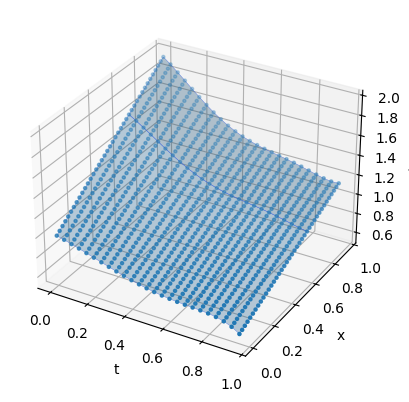

In [35]:
# Plot the solution of the first simulation job
_ = plt.figure()
ax = plt.axes(projection="3d")

#Construct the meshgrid for 3D plotting. 
t, x = np.meshgrid(t_samples, x_samples)

# plot the solution using the 3d plotting capabilities of pyplot
ax.plot_surface(
    t,
    x,
    u_functions,
    edgecolor="royalblue",
    lw=0.25,
    rstride=26,
    cstride=26,
    alpha=0.3,
)
ax.scatter(t, x, u_functions, marker=".")
ax.set(xlabel="t", ylabel="x", zlabel="u(t,x)")

plt.show()

Do the same for the second job

In [37]:
### Write your code below here ###
#Retrieve the solution and use the solution object to retrieve the data used to plot
solution_2 = solution_job
t_samples_2 = solution["samples"]["t"]
x_samples_2 = solution["samples"]["x"]
u_functions_2 = solution["functions"]["u"]

Notice the difference of initial condition for the second run and its effect on
the result:

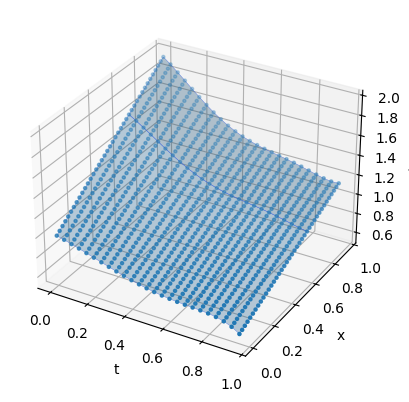

In [38]:
### Write your code below here ###
# Plot the solution of the second simulation job

# Plot the solution of the first simulation job
_ = plt.figure()
ax = plt.axes(projection="3d")

#Construct the meshgrid for 3D plotting. 
t, x = np.meshgrid(t_samples_2, x_samples_2)

# plot the solution using the 3d plotting capabilities of pyplot
ax.plot_surface(
    t,
    x,
    u_functions_2,
    edgecolor="royalblue",
    lw=0.25,
    rstride=26,
    cstride=26,
    alpha=0.3,
)
ax.scatter(t, x, u_functions_2, marker=".")
ax.set(xlabel="t", ylabel="x", zlabel="u(t,x)")

plt.show()

Note that for:

$a=1.0$ and $b=1.0$

we used (3+1+1)*10=50  qubits and 10000 shots per function evaluation to compute the loss function at each iteration steps were used.

While for

$a=0.5$ and $b=0.25$
 
we used (2+1+1)*10=40 qubits and a sequence of 500, 2000, 5000, 10000 was used with faster convergence. 

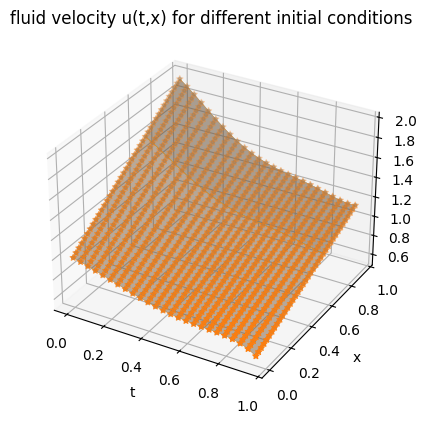

In [39]:
# Compare the solution for different initial condition, i.e
# a=1.0, b=1.0 vs a = 0.5, b=0.25
_ = plt.figure()
ax = plt.axes(projection="3d")

#Construct the meshgrid for 3D plotting. 
t, x = np.meshgrid(t_samples, x_samples)

# plot the solution using the 3d plotting capabilities of pyplot
ax.plot_surface(
    t,
    x,
    u_functions,
    edgecolor="royalblue",
    lw=0.25,
    rstride=26,
    cstride=26,
    alpha=0.3,
)
ax.plot_surface(
    t,
    x,
    u_functions_2,
    edgecolor="orange",
    lw=0.25,
    rstride=26,
    cstride=26,
    alpha=0.3,
)
ax.scatter(t, x, u_functions, marker=".")
ax.scatter(t, x, u_functions_2, marker="*")
ax.set(xlabel="t", ylabel="x")# zlabel="u(t,x)")
ax.set(title="fluid velocity u(t,x) for different initial conditions")
#ax.view_init(elev=15, azim=90)
#ax.set_zlim(0,2.0)
plt.show()

## Thank You for Participating!

Congratulations on completing **QUICK-PDE lab**! Today, you've delved into a multiphysics simulation Qiskit functions and learned how to solve a PDE on a quantum computer. You explored how these powerful tools can simplify quantum computing workflows and enhance your research and development projects.

As we continue through this summer school, remember that experimentation and iteration are at the heart of quantum development. Use the knowledge you gained today as a foundation for deeper explorations into Qiskit and quantum applications. We encourage you to keep testing, exploring, and sharing your findings with the Qiskit community.

Feel free to refer back to this notebook, check out the other track, revisit exercises, or try some of the optional sections to refine your skills. We hope this journey has inspired you to push the boundaries of quantum computing!

# Feedback Survey

We’d love to hear about your experience using the Qiskit Function! Your feedback is valuable and will help Qiskit Function providers enhance their tools and services. Please take a moment to share your thoughts by completing our short 2 min [feedback survey](https://airtable.com/app6VujlNUHZuOnAF/pagpw6TgP9UEt4TAT/form).

# Additional Information

**Created by**: Karla Baumann

**Advised by**: Junye Huang

**Version**: 1.1.0

## Qiskit packages versions

In [ ]:
import qiskit
import qiskit_ibm_catalog

print(f'Qiskit: {qiskit.__version__}')
print(f'Qiskit IBM Catalog: {qiskit_ibm_catalog.__version__}')